# Capítulo 16 — Ciclones Tropicais: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | o furacão como máquina de Carnot: intensidade potencial | NumPy |
| 2 | perfil de Holland: vento gradiente no olho e na parede | NumPy |
| 3 | intensidade potencial de verdade: `tcpyPI` numa sondagem | tcpyPI |
| 4 | maré de tempestade: vento empilha o mar na plataforma | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap16_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Omega = 9.8, 7.292e-5
rho_ar, rho_agua = 1.15, 1025.0

## Caso 1 — A máquina de Carnot de Emanuel

O furacão é um motor térmico: absorve calor do oceano a $T_s$, rejeita no topo da bigorna a $T_{out}$. A intensidade potencial máxima (MPI):
$$v_{max}^2 \;=\; \frac{C_k}{C_d}\,\frac{T_s - T_{out}}{T_{out}}\,\Delta k,$$
com $\Delta k$ o déficit de entalpia ar–mar (quanto ainda dá para evaporar). O limiar prático dos ~26,5 °C de TSM vem do crescimento explosivo de $\Delta k$ com Clausius–Clapeyron (Cap. 4).

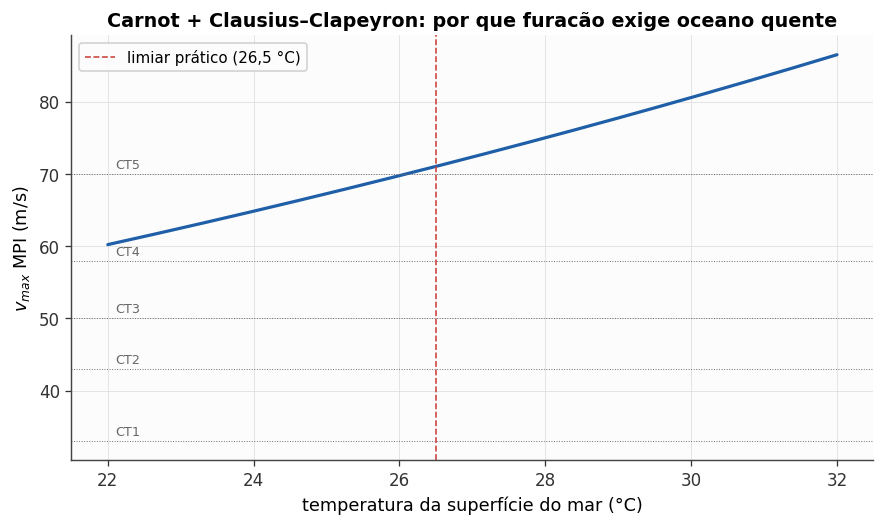

TSM 27 °C: MPI ~ 72 m/s | 30 °C: ~ 81 m/s
eficiencia de Carnot ~ (300-200)/200 = 50% — motor termico excepcional.


In [2]:
Ck_Cd, Lv, Cp = 0.9, 2.5e6, 1004.0
T_out = 200.0

def es_kPa(T_C):
    return 0.6113*np.exp(5423*(1/273.15 - 1/(T_C + 273.15)))

SSTs = np.linspace(22, 32, 200)
P_sfc = 101.3
r_sat = 622*es_kPa(SSTs)/(P_sfc - es_kPa(SSTs))          # g/kg saturado na TSM
dk = 0.2*Lv*r_sat/1000                                    # déficit ~20% da entalpia latente
Ts_K = SSTs + 273.15
eta = (Ts_K - T_out)/T_out
vmax = np.sqrt(Ck_Cd*eta*dk)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(SSTs, vmax, color=CORES['azul'], lw=2)
for lim, cat in [(33, 'CT1'), (43, 'CT2'), (50, 'CT3'), (58, 'CT4'), (70, 'CT5')]:
    ax.axhline(lim, color=CORES['cinza'], lw=0.6, ls=':')
    ax.text(22.1, lim + 0.8, cat, fontsize=8, color='#666666')
ax.axvline(26.5, color=CORES['vermelho'], ls='--', lw=1,
           label='limiar prático (26,5 °C)')
ax.set(xlabel='temperatura da superfície do mar (°C)', ylabel='$v_{max}$ MPI (m/s)',
       title='Carnot + Clausius–Clapeyron: por que furacão exige oceano quente')
ax.legend()
plt.show()
print(f'TSM 27 °C: MPI ~ {np.interp(27, SSTs, vmax):.0f} m/s | '
      f'30 °C: ~ {np.interp(30, SSTs, vmax):.0f} m/s')
print('eficiencia de Carnot ~ (300-200)/200 = 50% — motor termico excepcional.')

## Caso 2 — Perfil de Holland: a anatomia radial

Pressão de Holland (1980): $P(r) = P_c + \Delta P\,e^{-(R_w/r)^B}$. O vento gradiente (Cap. 10) com centrífuga E Coriolis:
$$v(r) = \sqrt{\frac{r}{\rho}\frac{dP}{dr} + \left(\frac{f r}{2}\right)^2} - \frac{|f|\,r}{2}.$$

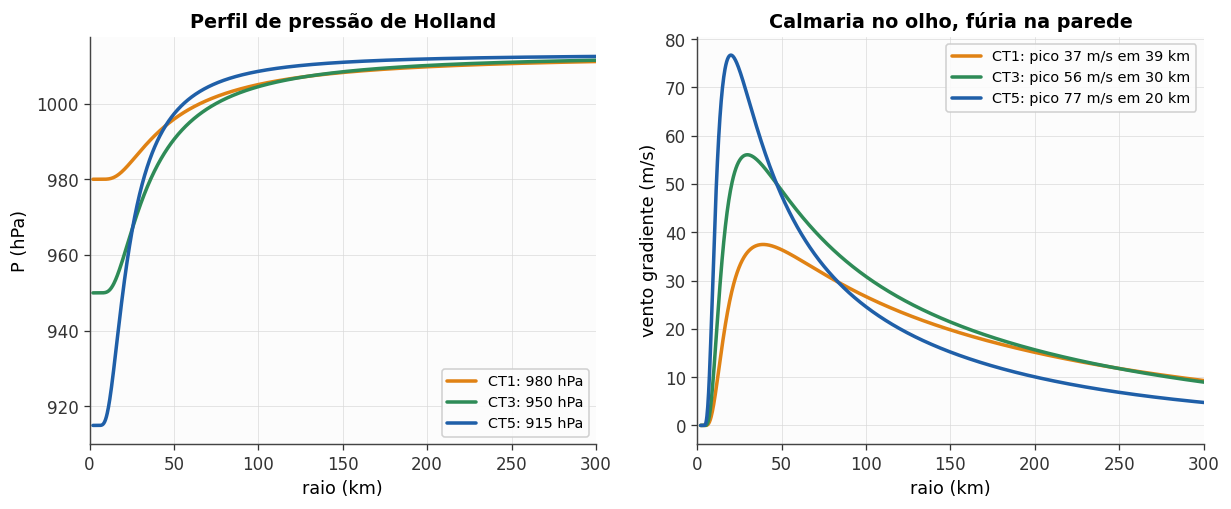

o vento maximo mora na parede do olho (r = R_w); dentro, o ar desce e o
ceu abre — o olho e a assinatura do nucleo quente em equilibrio.


In [3]:
f = np.abs(2*Omega*np.sin(np.deg2rad(-20)))
r = np.linspace(2e3, 500e3, 2000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
for Pc, Rw, B, cor, nome in [(98000, 40e3, 1.4, CORES['laranja'], 'CT1'),
                              (95000, 30e3, 1.6, CORES['verde'], 'CT3'),
                              (91500, 20e3, 1.9, CORES['azul'], 'CT5')]:
    dP = 101300 - Pc
    P = Pc + dP*np.exp(-(Rw/r)**B)
    dPdr = np.gradient(P, r)
    v = np.sqrt(np.maximum(r/rho_ar*dPdr, 0) + (f*r/2)**2) - f*r/2
    ax1.plot(r/1e3, P/100, color=cor, label=f'{nome}: {Pc/100:.0f} hPa')
    ax2.plot(r/1e3, v, color=cor,
             label=f'{nome}: pico {v.max():.0f} m/s em {r[np.argmax(v)]/1e3:.0f} km')
ax1.set(xlabel='raio (km)', ylabel='P (hPa)', xlim=(0, 300),
        title='Perfil de pressão de Holland')
ax1.legend(fontsize=9)
ax2.set(xlabel='raio (km)', ylabel='vento gradiente (m/s)', xlim=(0, 300),
        title='Calmaria no olho, fúria na parede')
ax2.legend(fontsize=9)
plt.show()
print('o vento maximo mora na parede do olho (r = R_w); dentro, o ar desce e o')
print('ceu abre — o olho e a assinatura do nucleo quente em equilibrio.')

## Caso 3 — MPI de verdade: `tcpyPI` (Bister & Emanuel)

O pacote `tcpyPI` implementa o cálculo completo de intensidade potencial a partir de uma sondagem tropical real (perfil de $T$ e $r$) e da TSM.

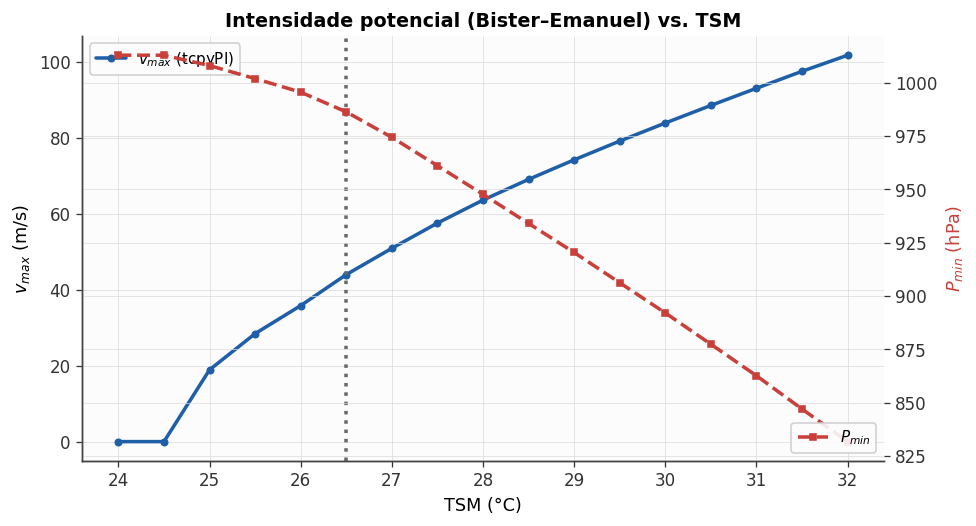

TSM 27 °C: v_max = 51 m/s, P_min = 974 hPa
TSM 30 °C: v_max = 84 m/s, P_min = 892 hPa
a MPI e um TETO termodinamico: cisalhamento e ar seco derrubam a real (N3).


In [4]:
from tcpyPI import pi as tc_pi

# sondagem tropical idealizada (superfície -> estratosfera)
P_lev = np.array([1000, 950, 900, 850, 800, 750, 700, 650, 600, 550, 500,
                  450, 400, 350, 300, 250, 200, 150, 100, 70, 50], dtype=float)
T_lev = np.array([27, 24.5, 22, 19.5, 17, 14.4, 11.5, 8.2, 4.6, 0.6, -3.8,
                  -8.8, -14.6, -21.4, -29.6, -39.5, -51.5, -66, -78, -75, -65], dtype=float)
r_lev = np.array([18, 16, 14, 12.5, 11, 9.5, 8, 6.5, 5.2, 4.0, 3.0,
                  2.2, 1.5, 1.0, 0.6, 0.3, 0.15, 0.05, 0.01, 0.005, 0.002], dtype=float)

SSTs = np.arange(24.0, 32.5, 0.5)
VM, PM = [], []
for sst in SSTs:
    vmax, pmin, ifl, T_o, otl = tc_pi(sst, 1013.0, P_lev, T_lev, r_lev)
    VM.append(vmax); PM.append(pmin)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(SSTs, VM, 'o-', ms=4, color=CORES['azul'], label='$v_{max}$ (tcpyPI)')
ax2 = ax.twinx()
ax2.plot(SSTs, PM, 's--', ms=4, color=CORES['vermelho'], label='$P_{min}$')
ax.axvline(26.5, color=CORES['cinza'], ls=':')
ax.set(xlabel='TSM (°C)', ylabel='$v_{max}$ (m/s)',
       title='Intensidade potencial (Bister–Emanuel) vs. TSM')
ax2.set_ylabel('$P_{min}$ (hPa)', color=CORES['vermelho'])
ax.legend(loc='upper left'); ax2.legend(loc='lower right')
plt.show()
i27 = np.argmin(np.abs(SSTs - 27)); i30 = np.argmin(np.abs(SSTs - 30))
print(f'TSM 27 °C: v_max = {VM[i27]:.0f} m/s, P_min = {PM[i27]:.0f} hPa')
print(f'TSM 30 °C: v_max = {VM[i30]:.0f} m/s, P_min = {PM[i30]:.0f} hPa')
print('a MPI e um TETO termodinamico: cisalhamento e ar seco derrubam a real (N3).')

## Caso 4 — Maré de tempestade

O vento empilha água contra a costa. No equilíbrio, a inclinação do mar equilibra a tensão do vento:
$$\frac{d\eta}{dx} = \frac{\tau_{vento}}{\rho_{agua}\,g\,h(x)},\qquad \tau = \rho_{ar}\,C_D\,V^2,$$
mais o **barômetro invertido** (~1 cm por hPa de queda). Plataforma rasa e larga = desastre.

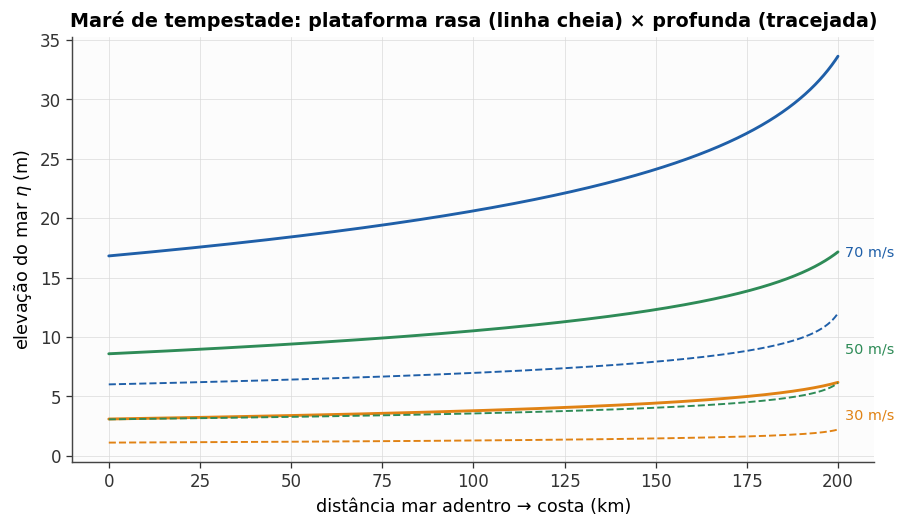

V = 30 m/s: surge  3.1 m (rasa) vs  1.1 m (profunda)  + barometro invertido ~0,5-1 m
V = 50 m/s: surge  8.6 m (rasa) vs  3.1 m (profunda)  + barometro invertido ~0,5-1 m
V = 70 m/s: surge 16.8 m (rasa) vs  6.0 m (profunda)  + barometro invertido ~0,5-1 m
a maré de tempestade — nao o vento — e o maior assassino dos ciclones tropicais.


In [5]:
C_D = 2.5e-3
L_plat = 200e3                                  # largura da plataforma
x = np.linspace(0, L_plat, 2000)

def surge(V, h0, h_costa=3.0):
    h = h0 + (h_costa - h0)*x/L_plat            # profundidade linear até a costa
    tau = rho_ar*C_D*V**2
    deta = tau/(rho_agua*g*h)
    return np.cumsum(deta)*np.gradient(x)

fig, ax = plt.subplots(figsize=(9, 4.8))
for V, cor in [(30, CORES['laranja']), (50, CORES['verde']), (70, CORES['azul'])]:
    for h0, ls in [(50.0, '-'), (200.0, '--')]:
        eta = surge(V, h0)
        ax.plot(x/1e3, eta[-1] - eta[::-1]*0 + eta, ls, color=cor, lw=1.8 if ls=='-' else 1.2)
    ax.text(202, surge(V, 50.0)[-1], f'{V} m/s', fontsize=9, color=cor)
ax.set(xlabel='distância mar adentro → costa (km)', ylabel='elevação do mar $\\eta$ (m)',
       title='Maré de tempestade: plataforma rasa (linha cheia) × profunda (tracejada)')
plt.show()
for V in [30, 50, 70]:
    s_rasa, s_prof = surge(V, 50.0)[-1], surge(V, 200.0)[-1]
    print(f'V = {V} m/s: surge {s_rasa:4.1f} m (rasa) vs {s_prof:4.1f} m (profunda)'
          f'  + barometro invertido ~0,5-1 m')
print('a maré de tempestade — nao o vento — e o maior assassino dos ciclones tropicais.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap16_solucoes.ipynb`**.

**N1** — Mapeie a MPI do Caso 1 no plano (TSM, $T_{out}$); quanto vale esfriar o topo da bigorna em 5 K em relação a aquecer o mar em 1 K?

**N2** — Ajuste o perfil de Holland ($P_c$, $R_w$, $B$) para reproduzir um furacão com vento máximo de 60 m/s em raio de 25 km, e reporte a categoria e o $\Delta P$.

**N3** — Com o `tcpyPI`, aqueça a sondagem inteira e a TSM de +2 K (clima futuro idealizado) e compare $v_{max}$ e $P_{min}$ com o presente; qual %/K de intensificação?

**N4** — Varra a largura da plataforma (50–400 km) e a profundidade inicial no modelo de surge e mapeie a elevação na costa para V = 50 m/s; que costas brasileiras seriam mais vulneráveis?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*